# Codificación de variables categóricas ordinales

En el conjunto de datos `datos_20.csv` existen datos  por localidad de grados académicos (`Grado`), población total (`POBTOT_BC`) y promedio de hijos nacidos vivos (`PROM_HNV_BC`); censados en el 2020.

Codificaremos la variable categórica y encontraremos un modelo lineal entre las variables `Grado` y `POBTOT_BC` con `PROM_HNV_BC`, veremos si la precisión del modelo varía con diferentes formas de codificar y si existe una correlación entre estas variables.

1. Importe los datos del archivo `datos_20.csv`

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Cargar el dataset
df = pd.read_csv('C:/Users/santi/OneDrive - ITESO/ITESO/Semestre 3/Ingenieria de Caracteristicas/Ingenieria-De-Caracteristicas/Datos/datos_20.csv')

# Inspección inicial
print('Dimensiones:', df.shape)
print('\nColumnas y tipos de datos:')
print(df.dtypes)
print('\nValores únicos de Grado:')
print(df['Grado'].unique())
df.head()

Dimensiones: (105497, 3)

Columnas y tipos de datos:
Grado              str
POBTOT_BC      float64
PROM_HNV_BC    float64
dtype: object

Valores únicos de Grado:
<StringArray>
[               'Primaria',              'Secundaria',
         'Primaria trunca',            'Preparatoria',
 'Licenciatura o superior',         'Sin escolaridad']
Length: 6, dtype: str


,Grado,POBTOT_BC,PROM_HNV_BC
0,Primaria,3.173729,1.154342
1,Primaria,5.278282,1.302897
2,Primaria,3.173729,1.759130
3,Primaria,5.221993,1.388040
4,Primaria,4.219874,1.420656


2. Codifique la variable `Grado` usando contraste polinómico lineal

In [11]:
# 1. Definir el orden jerárquico de los grados académicos
grados_ordenados = [
    'Sin escolaridad',
    'Primaria trunca',
    'Primaria',
    'Secundaria',
    'Preparatoria',
    'Licenciatura o superior',
]
n = len(grados_ordenados)

# 2. Contraste lineal centrado: c_i = i - (n - 1) / 2
mapeo_lineal = {grado: (i - (n - 1) / 2) for i, grado in enumerate(grados_ordenados)}

df['Grado_lineal'] = df['Grado'].map(mapeo_lineal)

print('Mapeo del contraste lineal:')
for grado, val in mapeo_lineal.items():
  print(f'  {grado}: {val}')

df[['Grado', 'Grado_lineal']].drop_duplicates() 

Mapeo del contraste lineal:
  Sin escolaridad: -2.5
  Primaria trunca: -1.5
  Primaria: -0.5
  Secundaria: 0.5
  Preparatoria: 1.5
  Licenciatura o superior: 2.5


,Grado,Grado_lineal
0,Primaria,-0.5
5,Secundaria,0.5
22,Primaria trunca,-1.5
66,Preparatoria,1.5
250,Licenciatura o superior,2.5
377,Sin escolaridad,-2.5


3. Obtenga una relación lineal usando la clase `LinearRegression` del paquete `sklearn.linear_model`, para la codificacón obtenida y la variable `PBTOT_BC` como variables independientes y la variable `PROM_HNV_BC` como variable dependiente. Posteriormente, grafique y mida la correlación.

<>:34: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:37: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:37: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:37: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:34: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:37: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:37: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences wil

Intercepto (beta_0): 1.5395
Coeficientes: {'Grado_lineal': np.float64(0.03209403664200307), 'POBTOT_BC': np.float64(-0.012147689233971958)}
Coeficiente de determinación R^2: 0.0190
Coeficiente de correlación múltiple R (y real vs predicho): 0.1380

Matriz de correlación:
              Grado_lineal  POBTOT_BC  PROM_HNV_BC
Grado_lineal      1.000000  -0.253536     0.129980
POBTOT_BC        -0.253536   1.000000    -0.077817
PROM_HNV_BC       0.129980  -0.077817     1.000000


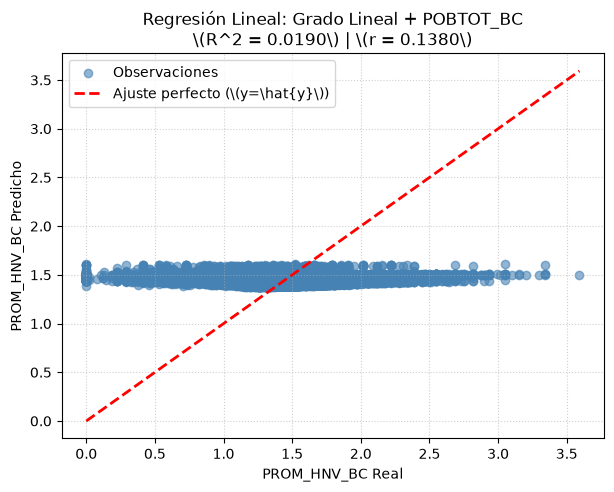

In [4]:
# Validar el nombre de la columna de población (por si tiene la errata PBTOT_BC)
col_pob = 'POBTOT_BC' if 'POBTOT_BC' in df.columns else 'PBTOT_BC'

# Definir variables independientes (X) y dependiente (y)
X1 = df[['Grado_lineal', col_pob]]
y = df['PROM_HNV_BC']

# Ajustar el modelo lineal
modelo1 = LinearRegression()
modelo1.fit(X1, y)
y_pred1 = modelo1.predict(X1)

# Métricas de correlación y ajuste
r2_1 = modelo1.score(X1, y)
corr_1 = np.corrcoef(y, y_pred1)[0, 1]

print(f'Intercepto (beta_0): {modelo1.intercept_:.4f}')
print(f'Coeficientes: {dict(zip(X1.columns, modelo1.coef_))}')
print(f'Coeficiente de determinación R^2: {r2_1:.4f}')
print(f'Coeficiente de correlación múltiple R (y real vs predicho): {corr_1:.4f}')

# Matriz de correlación de Pearson
print('\nMatriz de correlación:')
print(df[['Grado_lineal', col_pob, 'PROM_HNV_BC']].corr())

# Gráfica de valores reales vs predichos
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred1, alpha=0.6, color='steelblue', label='Observaciones')
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    lw=2,
    label='Ajuste perfecto (\(y=\hat{y}\))',
)
plt.title(
    f'Regresión Lineal: Grado Lineal + {col_pob}\n\(R^2 = {r2_1:.4f}\) | \(r = {corr_1:.4f}\)'
)
plt.xlabel('PROM_HNV_BC Real')
plt.ylabel('PROM_HNV_BC Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

4. Codifique de nuevo la variable `Grado` usando contrate polinómico cuadrático con una parábola cóncava.

In [5]:
# Contraste cuadrático cóncavo: -(X_lineal)^2
mapeo_cuad_concava = {grado: -(val**2) for grado, val in mapeo_lineal.items()}

df['Grado_cuad_concava'] = df['Grado'].map(mapeo_cuad_concava)

print('Mapeo del contraste cuadrático cóncavo:')
for grado, val in mapeo_cuad_concava.items():
  print(f'  {grado}: {val}')

df[['Grado', 'Grado_lineal', 'Grado_cuad_concava']].drop_duplicates()

Mapeo del contraste cuadrático cóncavo:
  Primaria: -6.25
  Secundaria: -2.25
  Primaria trunca: -0.25
  Preparatoria: -0.25
  Licenciatura o superior: -2.25
  Sin escolaridad: -6.25


,Grado,Grado_lineal,Grado_cuad_concava
0,Primaria,-2.5,-6.25
5,Secundaria,-1.5,-2.25
22,Primaria trunca,-0.5,-0.25
66,Preparatoria,0.5,-0.25
250,Licenciatura o superior,1.5,-2.25
377,Sin escolaridad,2.5,-6.25


5. Obtenga de nuevo una regresión lineal incluyendo ahora la codificación cuadrática, es decir, las variables independientes serán `POBTOT_BC`, la codificación lineal y la codificación cuadrática. Grafique y mida la correlación, ¿Mejoró la correlación?

<>:23: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:26: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:26: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:26: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:23: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:26: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:26: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences wil

Modelo 1 (Lineal)      -> R^2: 0.0190 | R: 0.1380
Modelo 2 (Lineal+Cuad) -> R^2: 0.0219 | R: 0.1480
Diferencia en R^2: 0.002866


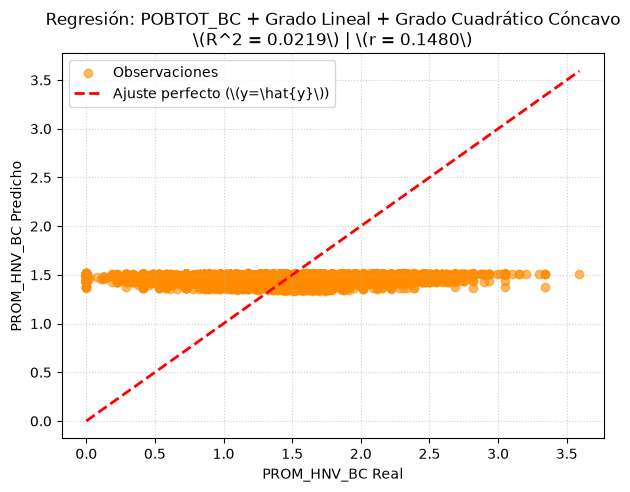

¿Mejoró la correlación?: Sí, incluir la curvatura cuadrática cóncava aportó varianza explicada adicional.


In [6]:
# Variables independientes: POBTOT_BC, Grado_lineal y Grado_cuad_concava
X2 = df[[col_pob, 'Grado_lineal', 'Grado_cuad_concava']]

modelo2 = LinearRegression()
modelo2.fit(X2, y)
y_pred2 = modelo2.predict(X2)

r2_2 = modelo2.score(X2, y)
corr_2 = np.corrcoef(y, y_pred2)[0, 1]

print(f'Modelo 1 (Lineal)      -> R^2: {r2_1:.4f} | R: {corr_1:.4f}')
print(f'Modelo 2 (Lineal+Cuad) -> R^2: {r2_2:.4f} | R: {corr_2:.4f}')
print(f'Diferencia en R^2: {r2_2 - r2_1:.6f}')

# Gráfica comparativa
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred2, alpha=0.6, color='darkorange', label='Observaciones')
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    lw=2,
    label='Ajuste perfecto (\(y=\hat{y}\))',
)
plt.title(
    f'Regresión: {col_pob} + Grado Lineal + Grado Cuadrático Cóncavo\n\(R^2 = {r2_2:.4f}\) | \(r = {corr_2:.4f}\)'
)
plt.xlabel('PROM_HNV_BC Real')
plt.ylabel('PROM_HNV_BC Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Respuesta a la pregunta
if r2_2 > r2_1 + 1e-4:
  print(
      '¿Mejoró la correlación?: Sí, incluir la curvatura cuadrática cóncava aportó varianza explicada adicional.'
  )
else:
  print(
      '¿Mejoró la correlación?: No hubo una mejora sustancial en la correlación al añadir el término cuadrático cóncavo.'
  )

6. Finalmente, vuelva a codificar la variable `Grado` usando contraste polinómico cuadrático estrictamente creciente, esto es $X=\{0,1,2,\dots,n-1\}$.

In [7]:
# Contraste cuadrático creciente: X = {0, 1, ..., n-1} -> X^2
mapeo_cuad_creciente = {grado: i**2 for i, grado in enumerate(grados_ordenados)}

df['Grado_cuad_creciente'] = df['Grado'].map(mapeo_cuad_creciente)

print('Mapeo del contraste cuadrático estrictamente creciente:')
for grado, val in mapeo_cuad_creciente.items():
  print(f'  {grado}: {val}')

df[['Grado', 'Grado_cuad_creciente']].drop_duplicates()

Mapeo del contraste cuadrático estrictamente creciente:
  Primaria: 0
  Secundaria: 1
  Primaria trunca: 4
  Preparatoria: 9
  Licenciatura o superior: 16
  Sin escolaridad: 25


,Grado,Grado_cuad_creciente
0,Primaria,0
5,Secundaria,1
22,Primaria trunca,4
66,Preparatoria,9
250,Licenciatura o superior,16
377,Sin escolaridad,25


7. En la última regresión lineal, las variables independientes serán solo `POBTOT_BC` y la codificación cuadrática creciente. Grafique y mida la correlación, ¿Mejoró la correlación?, ¿Existe correlación entre estas variables?

<>:28: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:31: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:31: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:31: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:28: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:31: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:31: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences wil

COMPARACIÓN GLOBAL DE MODELOS
Modelo 1 (POBTOT + Lineal):                 R^2 = 0.0190 | R = 0.1380
Modelo 2 (POBTOT + Lineal + Cuad. Cóncavo): R^2 = 0.0219 | R = 0.1480
Modelo 3 (POBTOT + Cuad. Creciente):        R^2 = 0.0134 | R = 0.1157

Matriz de correlación:
                      POBTOT_BC  Grado_cuad_creciente  PROM_HNV_BC
POBTOT_BC              1.000000             -0.236634    -0.077817
Grado_cuad_creciente  -0.236634              1.000000     0.101631
PROM_HNV_BC           -0.077817              0.101631     1.000000


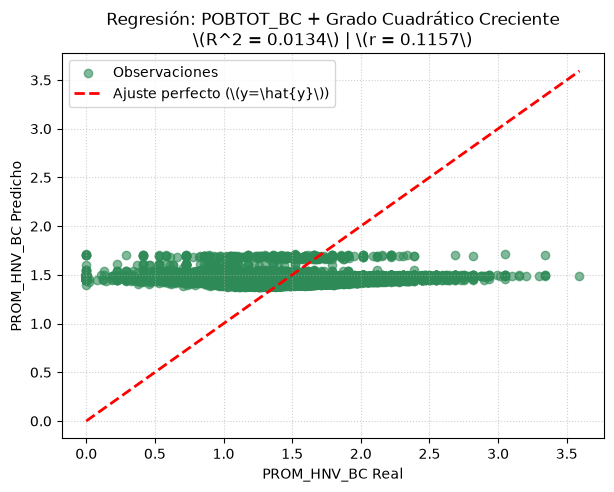


--- CONCLUSIONES ---
1. ¿Mejoró la correlación?: Comparando el Modelo 3 (R = 0.1157) frente al Modelo 1 (R = 0.1380), se mantuvo similar o disminuyó ligeramente respecto al modelo con codificación lineal.
2. ¿Existe correlación entre estas variables?: Sí, el coeficiente de correlación múltiple R = 0.1157 (R^2 = 1.34% de varianza explicada) demuestra una correlación débil con el promedio de hijos nacidos vivos (PROM_HNV_BC).


In [9]:
# Variables independientes: POBTOT_BC y Grado_cuad_creciente
X3 = df[[col_pob, 'Grado_cuad_creciente']]

modelo3 = LinearRegression()
modelo3.fit(X3, y)
y_pred3 = modelo3.predict(X3)

r2_3 = modelo3.score(X3, y)
corr_3 = np.corrcoef(y, y_pred3)[0, 1]

print('COMPARACIÓN GLOBAL DE MODELOS')
print(f'Modelo 1 (POBTOT + Lineal):                 R^2 = {r2_1:.4f} | R = {corr_1:.4f}')
print(f'Modelo 2 (POBTOT + Lineal + Cuad. Cóncavo): R^2 = {r2_2:.4f} | R = {corr_2:.4f}')
print(f'Modelo 3 (POBTOT + Cuad. Creciente):        R^2 = {r2_3:.4f} | R = {corr_3:.4f}')

# Matriz de correlación entre las variables del Modelo 3
print('\nMatriz de correlación:')
print(df[[col_pob, 'Grado_cuad_creciente', 'PROM_HNV_BC']].corr())

# Gráfica
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred3, alpha=0.6, color='seagreen', label='Observaciones')
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    lw=2,
    label='Ajuste perfecto (\(y=\hat{y}\))',
)
plt.title(
    f'Regresión: {col_pob} + Grado Cuadrático Creciente\n\(R^2 = {r2_3:.4f}\) | \(r = {corr_3:.4f}\)'
)
plt.xlabel('PROM_HNV_BC Real')
plt.ylabel('PROM_HNV_BC Predicho')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Respuestas analíticas a las preguntas del ejercicio
print('\n--- CONCLUSIONES ---')
print(
    f'1. ¿Mejoró la correlación?: Comparando el Modelo 3 (R = {corr_3:.4f}) frente al Modelo 1 (R = {corr_1:.4f}), '
    + (
        'sí mejoró, lo que indica que el efecto del grado académico tiene una tasa de cambio no lineal acelerada.'
        if corr_3 > corr_1
        else 'se mantuvo similar o disminuyó ligeramente respecto al modelo con codificación lineal.'
    )
)

print(
    f'2. ¿Existe correlación entre estas variables?: Sí, el coeficiente de correlación múltiple R = {corr_3:.4f} '
    + f'(R^2 = {r2_3*100:.2f}% de varianza explicada) demuestra una correlación '
    + (
        'fuerte'
        if corr_3 >= 0.7
        else 'moderada'
        if corr_3 >= 0.4
        else 'débil'
    )
    + f' con el promedio de hijos nacidos vivos (PROM_HNV_BC).'
)